# M6-B1 — Analyse de dérive (à compléter)

## 1. Exploration — distributions référence vs prod

Variables numériques (8): ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'revol_util']
Variables catégorielles (6): ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose']


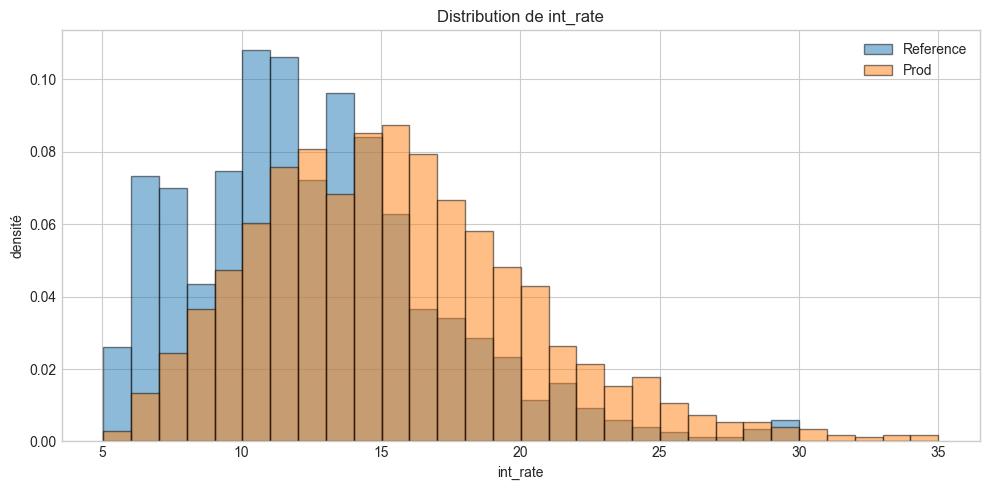

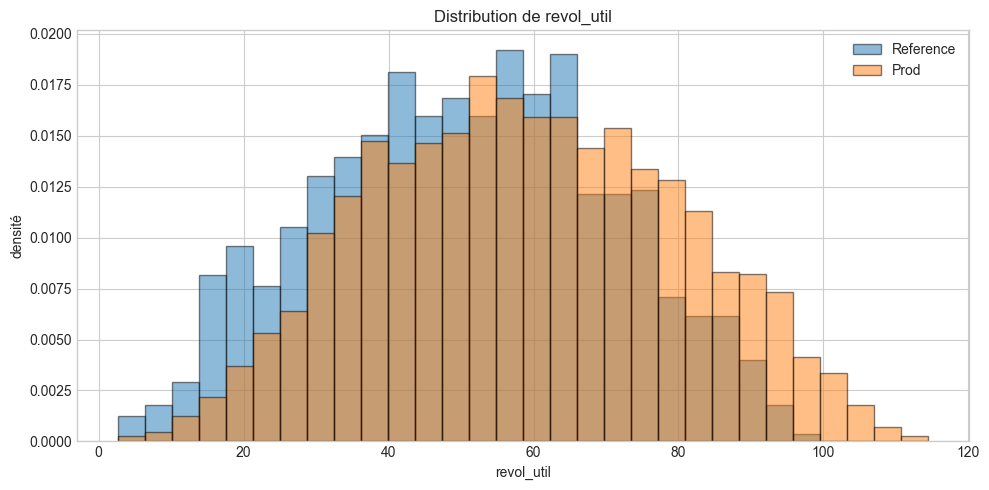

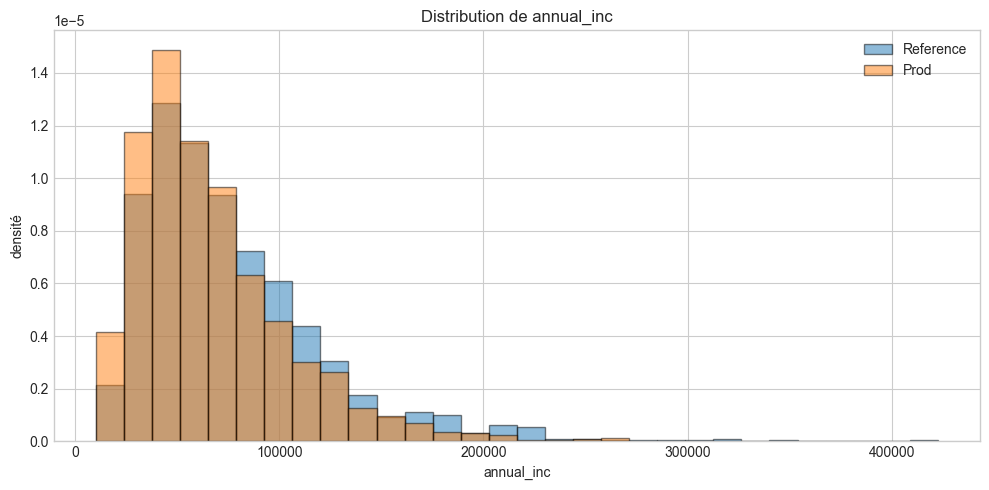

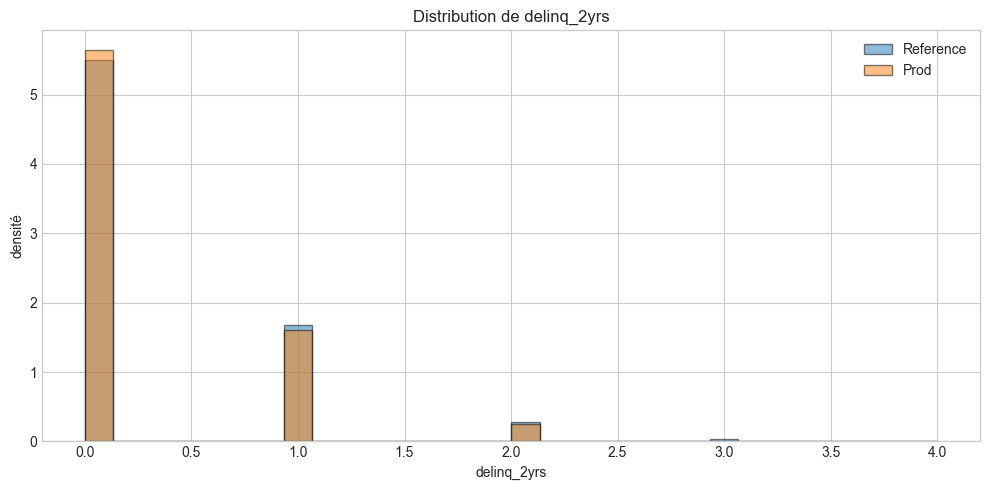

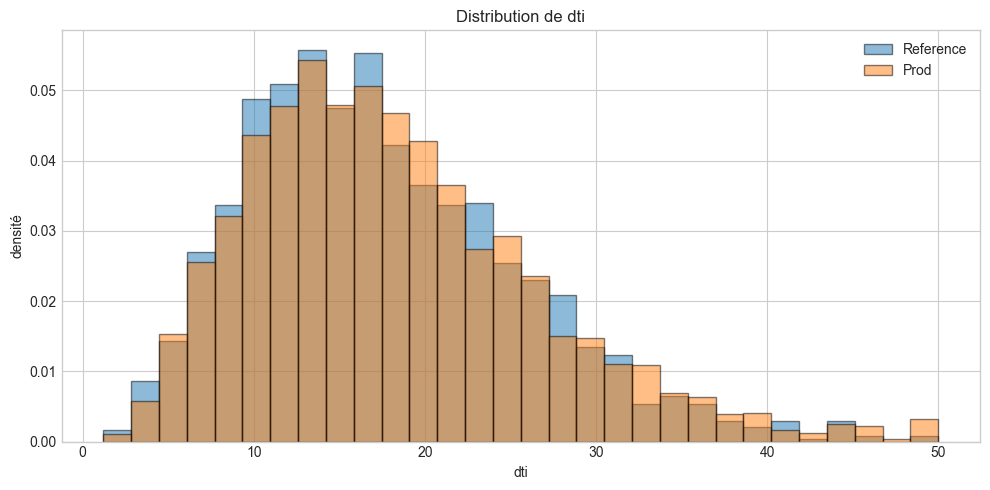

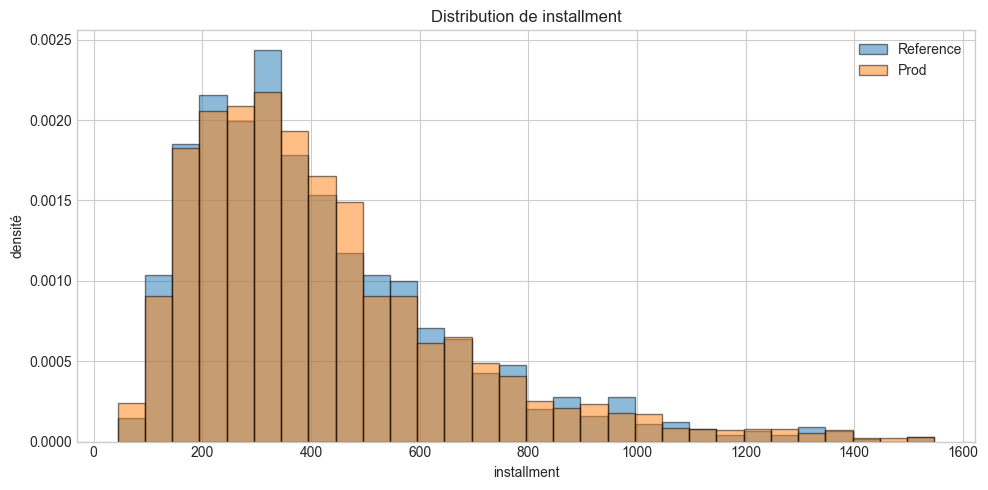

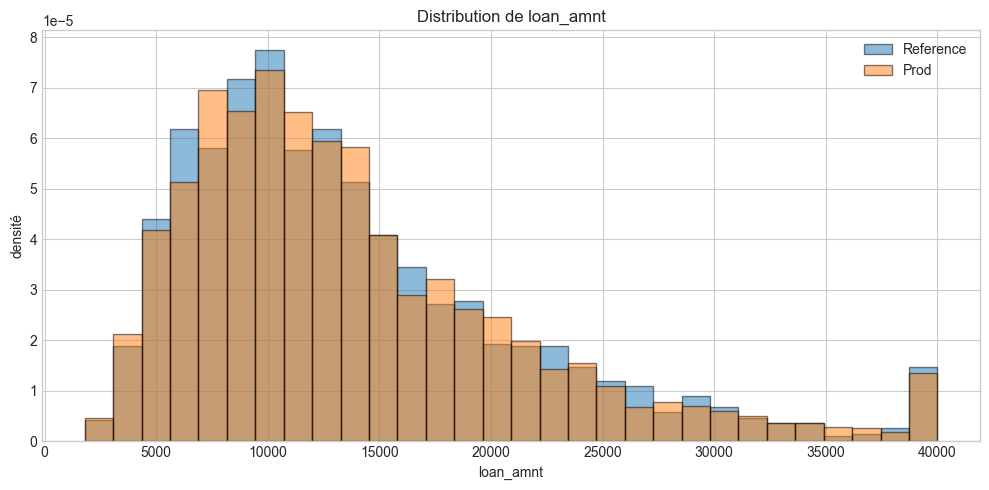

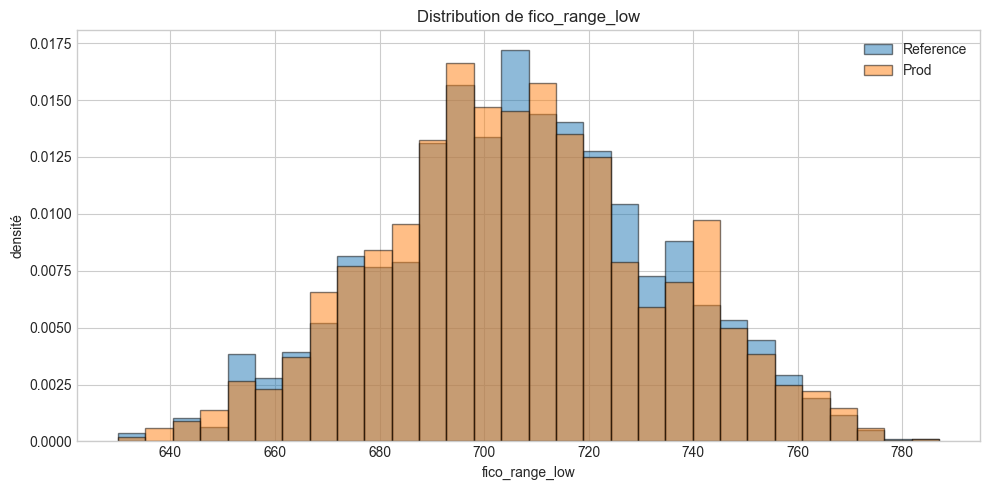

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

root = Path.cwd().resolve().parent
ref = pd.read_csv(root / "data" / "reference_set.csv")
prod = pd.read_csv(root / "data" / "prod_3months.csv")

# --- 0) Préparation ---
exclude_cols = {"loan_status", "timestamp"}
feature_cols = [c for c in ref.columns if c not in exclude_cols and c in prod.columns]

numeric_cols = [
    c for c in feature_cols
    if pd.api.types.is_numeric_dtype(ref[c]) and pd.api.types.is_numeric_dtype(prod[c])
]
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

print(f"Variables numériques ({len(numeric_cols)}): {numeric_cols}")
print(f"Variables catégorielles ({len(categorical_cols)}): {categorical_cols}")

# --- 1) Comparaison visuelle des distributions numériques ---
# Représentation en superposition transparente.
priority_cols = ["int_rate", "revol_util", "annual_inc", "delinq_2yrs", "dti", "installment"]

for col in [c for c in priority_cols if c in numeric_cols]:
    ref_vals = ref[col].dropna()
    prod_vals = prod[col].dropna()
    min_val = min(ref_vals.min(), prod_vals.min())
    max_val = max(ref_vals.max(), prod_vals.max())
    bins = np.linspace(min_val, max_val, 31)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(ref_vals, bins=bins, density=True, alpha=0.5, color="tab:blue", edgecolor="black", label="Reference")
    ax.hist(prod_vals, bins=bins, density=True, alpha=0.5, color="tab:orange", edgecolor="black", label="Prod")
    ax.set_title(f"Distribution de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("densité")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Les autres variables numériques peuvent aussi être vérifiées rapidement.
for col in [c for c in numeric_cols if c not in priority_cols]:
    ref_vals = ref[col].dropna()
    prod_vals = prod[col].dropna()
    min_val = min(ref_vals.min(), prod_vals.min())
    max_val = max(ref_vals.max(), prod_vals.max())
    bins = np.linspace(min_val, max_val, 31)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(ref_vals, bins=bins, density=True, alpha=0.5, color="tab:blue", edgecolor="black", label="Reference")
    ax.hist(prod_vals, bins=bins, density=True, alpha=0.5, color="tab:orange", edgecolor="black", label="Prod")
    ax.set_title(f"Distribution de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("densité")
    ax.legend()
    plt.tight_layout()
    plt.show()



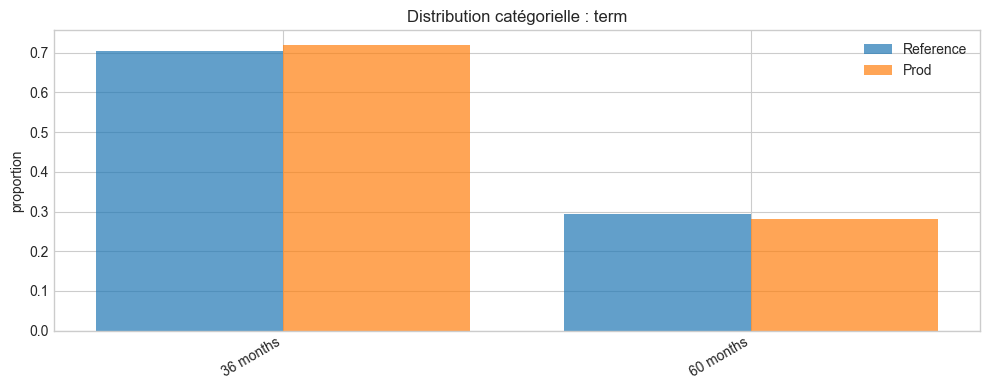

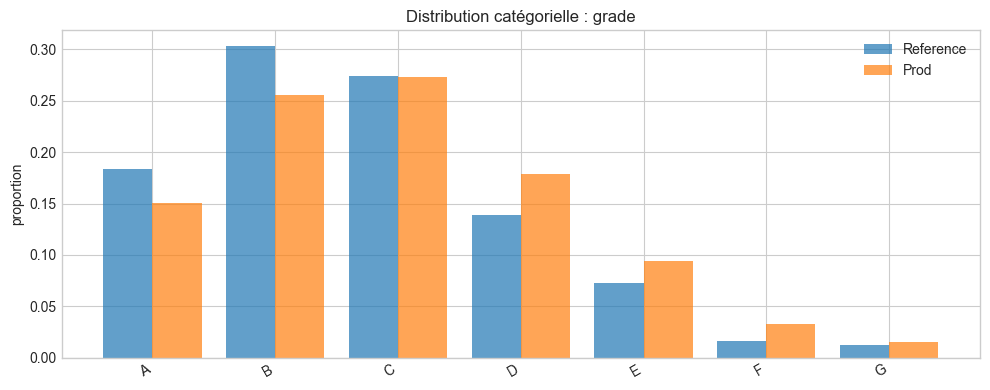

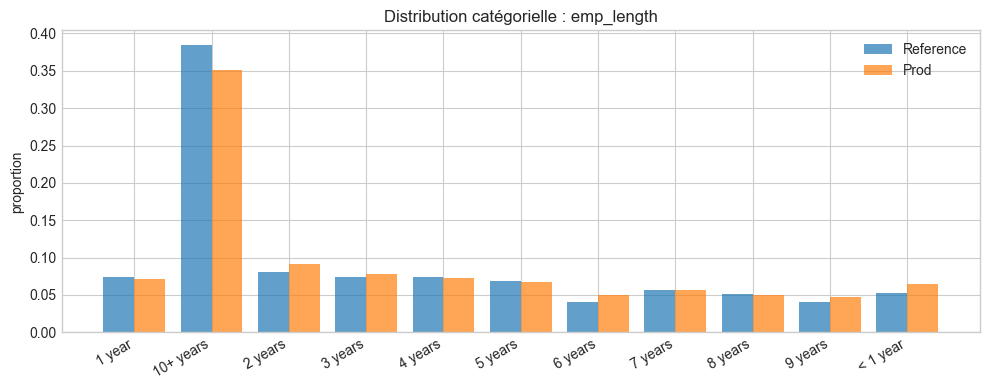

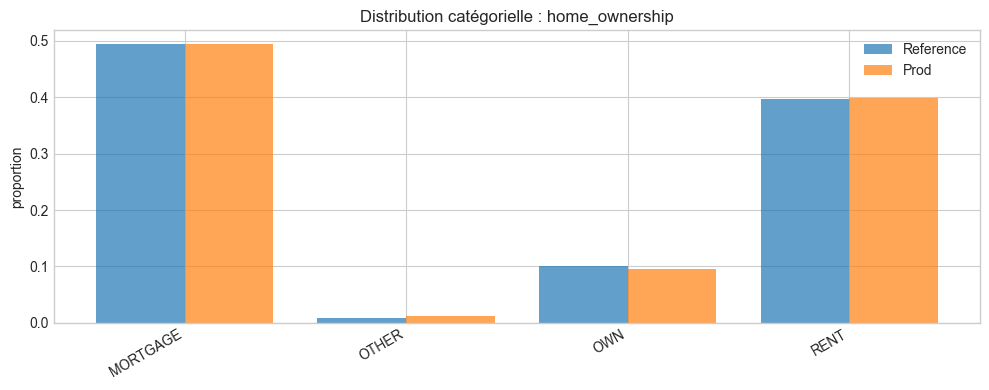

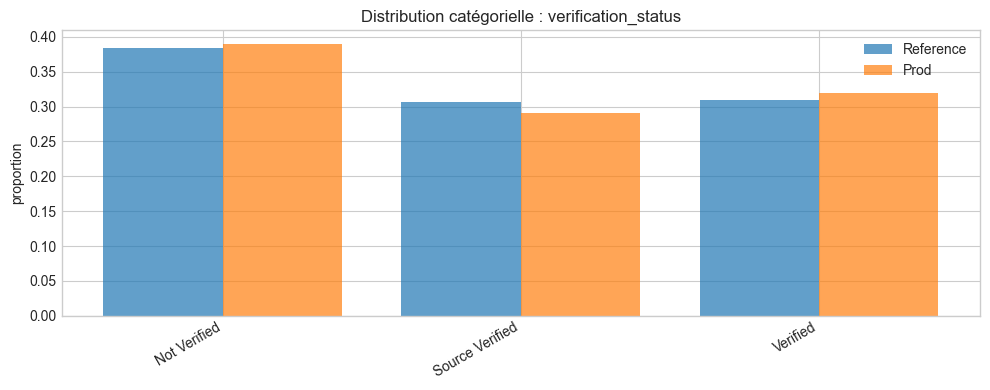

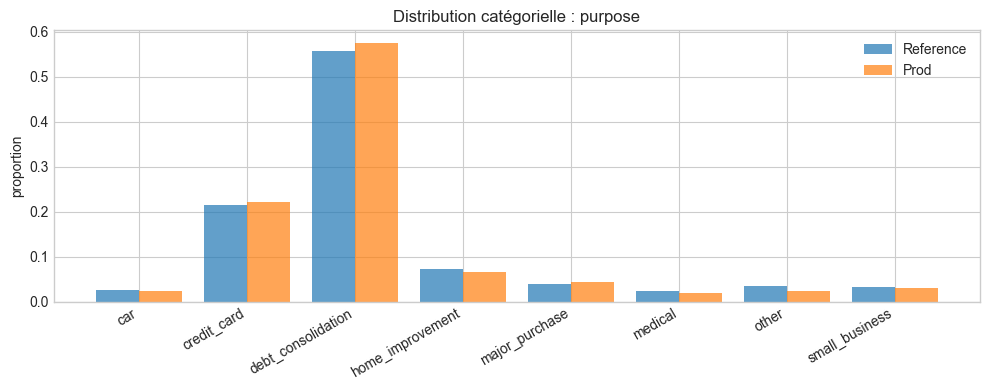

In [3]:
# --- 2) Comparaison des variables catégorielles ---
for col in categorical_cols:
    ref_counts = ref[col].dropna().astype(str).value_counts(normalize=True)
    prod_counts = prod[col].dropna().astype(str).value_counts(normalize=True)
    categories = sorted(set(ref_counts.index) | set(prod_counts.index), key=lambda x: str(x))

    ref_prop = ref_counts.reindex(categories, fill_value=0)
    prod_prop = prod_counts.reindex(categories, fill_value=0)

    x = np.arange(len(categories))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(x - 0.2, ref_prop.values, width=0.4, alpha=0.7, label="Reference")
    ax.bar(x + 0.2, prod_prop.values, width=0.4, alpha=0.7, label="Prod")
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=30, ha="right")
    ax.set_ylabel("proportion")
    ax.set_title(f"Distribution catégorielle : {col}")
    ax.legend()
    plt.tight_layout()
    plt.show()



In [5]:
# --- 3) Résumé quantitatif pour repérer les écarts importants ---
summary = []
for col in numeric_cols:
    ref_vals = ref[col].dropna()
    prod_vals = prod[col].dropna()
    summary.append({
        "feature": col,
        "ref_mean": round(ref_vals.mean(), 3),
        "prod_mean": round(prod_vals.mean(), 3),
        "ref_median": round(ref_vals.median(), 3),
        "prod_median": round(prod_vals.median(), 3),
        "ref_std": round(ref_vals.std(), 3),
        "prod_std": round(prod_vals.std(), 3),
        "missing_ref": round(ref[col].isna().mean(), 3),
        "missing_prod": round(prod[col].isna().mean(), 3),
    })

summary_df = pd.DataFrame(summary)
print("\nRésumé descriptif des variables numériques :")
print(summary_df.to_string(index=False))

# --- 4) Features à examiner en premier ---
priority = ["int_rate", "revol_util", "annual_inc", "delinq_2yrs", "dti", "installment"]
print("\nColonnes à prioriser pour l'investigation :")
print([c for c in priority if c in numeric_cols])




Résumé descriptif des variables numériques :
       feature  ref_mean  prod_mean  ref_median  prod_median   ref_std  prod_std  missing_ref  missing_prod
     loan_amnt 13828.400  13800.067    11900.00    11900.000  7761.013  7680.036        0.000         0.000
      int_rate    12.613     15.499       12.01       15.085     4.473     4.924        0.000         0.000
   installment   417.861    421.532      354.45      362.560   246.171   249.186        0.000         0.000
    annual_inc 76938.400  67156.464    65950.00    57935.500 45641.436 39129.825        0.000         0.000
           dti    17.564     18.201       16.48       16.945     8.048     8.491        0.000         0.000
   delinq_2yrs     0.312      0.282        0.00        0.000     0.562     0.524        0.000         0.000
fico_range_low   707.366    706.686      707.00      706.000    26.371    26.632        0.000         0.000
    revol_util    50.574     58.962       50.90       58.400    20.013    21.162        0.

## 2. Détection statistique — PSI · KS · Chi²

In [6]:
import sys

sys.path.append(str(root))

from src.drift_detection import PSI_DRIFT, PSI_STABLE, drift_report
ALPHA = 0.05  # seuil de significativité, côté analyse


In [7]:
report = drift_report(ref, prod, numeric_cols, categorical_cols)

print(f"{len(report)} features testées "
      f"({len(numeric_cols)} numériques, {len(categorical_cols)} catégorielles)")

display(report.style
        .format({"psi": "{:.3f}", "ks_pvalue": "{:.2e}", "chi2_pvalue": "{:.2e}"})
        .background_gradient(subset=["psi"], cmap="OrRd"))

14 features testées (8 numériques, 6 catégorielles)


,type,psi,ks_pvalue,chi2_pvalue,verdict
feature,,,,,
int_rate,numerique,0.444,4.63e-65,nan,dérive
revol_util,numerique,0.187,3.82e-20,nan,suspect
annual_inc,numerique,0.067,2.28e-09,nan,stable
grade,categorielle,0.043,nan,3.65e-07,stable
installment,numerique,0.015,6.63e-01,nan,stable
dti,numerique,0.011,1.10e-01,nan,stable
emp_length,categorielle,0.010,nan,4.92e-01,stable
purpose,categorielle,0.009,nan,1.99e-01,stable
fico_range_low,numerique,0.007,4.89e-01,nan,stable


In [8]:
# --- Correction des tests multiples (Holm-Bonferroni) ---
# Sur N features à alpha = 0.05, P(au moins un faux positif) = 1 - 0.95**N
# (~58 % pour 17 features). Sans correction, "tout dérive" est garanti.
report["p_value"] = report["ks_pvalue"].fillna(report["chi2_pvalue"])

ordered = report["p_value"].dropna().sort_values()
n_tests, significant, rejecting = len(ordered), {}, True
for rank, (feature, p) in enumerate(ordered.items()):
    rejecting = rejecting and (p <= ALPHA / (n_tests - rank))
    significant[feature] = rejecting  # dès qu'un test échoue, les suivants aussi
report["signif_holm"] = report.index.map(significant).fillna(False)

print(f"significatives brut : {int((report['p_value'] < ALPHA).sum())} | "
      f"après Holm : {int(report['signif_holm'].sum())}")


def commentaire(row: pd.Series) -> str:
    """L'ampleur commande, la p-value confirme."""
    if row["verdict"] == "stable":
        return ("significativité portée par la taille d'échantillon, ampleur faible"
                if row["signif_holm"] else "aucun signal")
    if row["type"] == "numerique":
        mean_ref = ref[row.name].mean()
        if mean_ref:
            return f"signaux concordants, moyenne {100 * (prod[row.name].mean() - mean_ref) / abs(mean_ref):+.1f} %"
    return "signaux concordants, modalités redistribuées"


report["commentaire"] = report.apply(commentaire, axis=1)
display(report[["type", "psi", "p_value", "signif_holm", "verdict", "commentaire"]]
        .style.format({"psi": "{:.3f}", "p_value": "{:.2e}"}))

significatives brut : 4 | après Holm : 4


,type,psi,p_value,signif_holm,verdict,commentaire
feature,,,,,,
int_rate,numerique,0.444,4.63e-65,True,dérive,"signaux concordants, moyenne +22.9 %"
revol_util,numerique,0.187,3.82e-20,True,suspect,"signaux concordants, moyenne +16.6 %"
annual_inc,numerique,0.067,2.28e-09,True,stable,"significativité portée par la taille d'échantillon, ampleur faible"
grade,categorielle,0.043,3.65e-07,True,stable,"significativité portée par la taille d'échantillon, ampleur faible"
installment,numerique,0.015,6.63e-01,False,stable,aucun signal
dti,numerique,0.011,1.10e-01,False,stable,aucun signal
emp_length,categorielle,0.010,4.92e-01,False,stable,aucun signal
purpose,categorielle,0.009,1.99e-01,False,stable,aucun signal
fico_range_low,numerique,0.007,4.89e-01,False,stable,aucun signal


## 3. Calibration en exploitation

In [ ]:
# TODO


## 4. Performance dans le temps

In [ ]:
# TODO


## 5. Diagnostic & recommandation

In [ ]:
# TODO
